# E-Commerce EDA & Data Preparation — Olist Brazilian E-Commerce Dataset

**Latihan Portofolio Data Analyst — oleh Yogs**

Proyek ini terinspirasi dari notebook Kaggle [*E-Commerce Sentiment Analysis: EDA + Viz + NLP*](https://www.kaggle.com/code/thiagopanini/e-commerce-sentiment-analysis-eda-viz-nlp) oleh Thiago Panini. Karena notebook aslinya berbahasa Portugis (Brazil) dan hanya menampilkan output statis di Kaggle, proyek ini dibangun ulang dari nol dengan alur kerja, narasi, dan interpretasi bisnis versi sendiri — dengan fokus khusus pada tiga skill inti seorang Data Analyst:

1. **Data Understanding & Cleaning** (Data Preparation)
2. **Exploratory Data Analysis (EDA)**
3. **Data Visualization**

Bagian *sentiment analysis / NLP* pada notebook asli sengaja tidak direplikasi di tahap ini karena teks ulasan pelanggan berbahasa Portugis (butuh pipeline NLP terpisah) — dan memang bukan fokus latihan kali ini. Notebook ini adalah **fase 1** dari rencana besar: hasil akhirnya (dataset yang sudah bersih) akan menjadi fondasi untuk **dashboard/web app** pada fase berikutnya.

---

## 1. Konteks Bisnis

**Olist** adalah salah satu marketplace terbesar di Brazil yang menjadi jembatan antara UMKM (seller kecil-menengah) dengan pelanggan di berbagai channel marketplace. Dataset ini berisi ±100 ribu transaksi nyata (2016–2018) yang mencakup informasi pesanan, pembayaran, produk, review, hingga lokasi seller/customer.

## 2. Pertanyaan Bisnis yang Ingin Dijawab

1. Bagaimana tren penjualan Olist dari waktu ke waktu? Apakah ada pola musiman?
2. Seberapa baik performa pengiriman (delivery performance) Olist — apakah sering terlambat, dan apakah itu memengaruhi kepuasan pelanggan?
3. Kategori produk apa yang paling laris dan paling menyumbang revenue?
4. Bagaimana metode pembayaran yang paling banyak digunakan pelanggan?
5. Dari mana saja mayoritas pelanggan dan seller berasal secara geografis?
6. Apakah Olist punya basis pelanggan yang loyal (repeat customer), atau didominasi pembeli satu kali?
7. Faktor apa yang paling berkorelasi dengan review score rendah?

## 3. Tentang Dataset

Dataset resmi *Brazilian E-Commerce Public Dataset by Olist* terdiri dari **9 tabel relasional** (bukan satu flat file), sehingga tahap *data preparation* — menggabungkan tabel menjadi satu *Analytical Base Table (ABT)* — menjadi bagian penting dari latihan ini.

| Tabel | Isi | Grain (1 baris =) |
|---|---|---|
| `olist_orders_dataset` | Status & timestamp tiap tahap pesanan | 1 order |
| `olist_order_items_dataset` | Item yang dibeli dalam tiap order | 1 item dalam order |
| `olist_order_payments_dataset` | Detail pembayaran | 1 transaksi pembayaran |
| `olist_order_reviews_dataset` | Skor & komentar review pelanggan | 1 review |
| `olist_customers_dataset` | ID & lokasi pelanggan | 1 customer (per order) |
| `olist_products_dataset` | Atribut produk (kategori, dimensi, berat) | 1 produk |
| `olist_sellers_dataset` | ID & lokasi seller | 1 seller |
| `olist_geolocation_dataset` | Peta zip code ↔ lat/lng Brazil | 1 titik geolokasi |
| `product_category_name_translation` | Terjemahan nama kategori PT → EN | 1 kategori |

> **Catatan reproduksi:** Data mentah tidak disertakan dalam repo (praktik umum — raw data besar sebaiknya tidak di-commit ke Git). Unduh dataset dari link Kaggle di atas, lalu letakkan ke-9 file CSV-nya di `data/raw/` sebelum menjalankan notebook ini.

## 1. Setup & Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Konsisten visual style untuk semua chart di notebook ini
sns.set_theme(style="whitegrid", font_scale=1.0)
PALETTE = "viridis"
ACCENT = "#2E86AB"
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

## 2. Data Collection

Memuat seluruh 9 tabel mentah dari `data/raw/`.

In [4]:
RAW_DIR = "data/raw"

files = {
    "orders": f"{RAW_DIR}/olist_orders_dataset.csv",
    "items": f"{RAW_DIR}/olist_order_items_dataset.csv",
    "payments": f"{RAW_DIR}/olist_order_payments_dataset.csv",
    "reviews": f"{RAW_DIR}/olist_order_reviews_dataset.csv",
    "customers": f"{RAW_DIR}/olist_customers_dataset.csv",
    "products": f"{RAW_DIR}/olist_products_dataset.csv",
    "sellers": f"{RAW_DIR}/olist_sellers_dataset.csv",
    "geoloc": f"{RAW_DIR}/olist_geolocation_dataset.csv",
    "cat_translation": f"{RAW_DIR}/product_category_name_translation.csv",
}

dfs = {name: pd.read_csv(path) for name, path in files.items()}

summary = pd.DataFrame({
    "n_rows": {k: v.shape[0] for k, v in dfs.items()},
    "n_cols": {k: v.shape[1] for k, v in dfs.items()},
}).sort_values("n_rows", ascending=False)
summary

,n_rows,n_cols
geoloc,1000163,5
items,112650,7
payments,103886,5
orders,99441,8
customers,99441,5
reviews,99224,7
products,32951,9
sellers,3095,4
cat_translation,71,2


## 3. Data Understanding (Initial Exploration)

Sebelum membersihkan data, kita perlu memahami dulu: tipe data tiap kolom, missing values, duplikasi, dan konsistensi key antar tabel.

In [5]:
orders = dfs["orders"]
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


### 3.1 Missing Values per Tabel

In [4]:
missing_report = []
for name, df in dfs.items():
    miss = df.isna().sum()
    miss = miss[miss > 0]
    for col, n in miss.items():
        missing_report.append({"table": name, "column": col, "n_missing": n,
                                "pct_missing": round(n / len(df) * 100, 2)})

missing_df = pd.DataFrame(missing_report).sort_values(["table", "pct_missing"], ascending=[True, False])
missing_df

,table,column,n_missing,pct_missing
2,orders,order_delivered_customer_date,2965,2.98
1,orders,order_delivered_carrier_date,1783,1.79
0,orders,order_approved_at,160,0.16
5,products,product_category_name,610,1.85
6,products,product_name_lenght,610,1.85
7,products,product_description_lenght,610,1.85
8,products,product_photos_qty,610,1.85
9,products,product_weight_g,2,0.01
10,products,product_length_cm,2,0.01
11,products,product_height_cm,2,0.01


**Interpretasi missing values (bukan sekadar "data kotor", tapi punya makna bisnis):**

- `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` pada tabel `orders` hilang karena order tersebut memang **belum mencapai tahap itu** (misalnya order dibatalkan sebelum diproses, atau statusnya masih `shipped`) — bukan error input.
- `review_comment_title` & `review_comment_message` hilang karena pelanggan **memberi skor tanpa menulis komentar** — perilaku wajar, bukan data hilang yang perlu diisi paksa.
- `product_category_name` dan atribut dimensi produk hilang pada 610 produk — kemungkinan produk lama yang belum lengkap datanya saat didaftarkan seller.

### 3.2 Duplikasi & Konsistensi Key

In [5]:
dup_report = {name: df.duplicated().sum() for name, df in dfs.items()}
print("Baris duplikat penuh per tabel:")
for k, v in dup_report.items():
    print(f"  {k:16s}: {v:,}")

print()
print(f"order_id unik di 'orders'      : {dfs['orders']['order_id'].nunique():,} dari {len(dfs['orders']):,} baris")
print(f"order_id duplikat di 'reviews' : {dfs['reviews']['order_id'].duplicated().sum():,} (ada order dgn >1 review)")
print(f"order_id duplikat di 'payments': {dfs['payments']['order_id'].duplicated().sum():,} (wajar, 1 order bisa >1 metode bayar)")
print(f"order_id duplikat di 'items'   : {dfs['items']['order_id'].duplicated().sum():,} (wajar, order berisi >1 item)")
print()
print(f"customer_id unik   : {dfs['customers']['customer_id'].nunique():,}")
print(f"customer_unique_id : {dfs['customers']['customer_unique_id'].nunique():,}  <-- lebih kecil, artinya ada pelanggan yang order berkali-kali")

Baris duplikat penuh per tabel:
  orders          : 0
  items           : 0
  payments        : 0
  reviews         : 0
  customers       : 0
  products        : 0
  sellers         : 0
  geoloc          : 261,831
  cat_translation : 0

order_id unik di 'orders'      : 99,441 dari 99,441 baris
order_id duplikat di 'reviews' : 551 (ada order dgn >1 review)
order_id duplikat di 'payments': 4,446 (wajar, 1 order bisa >1 metode bayar)
order_id duplikat di 'items'   : 13,984 (wajar, order berisi >1 item)

customer_id unik   : 99,441
customer_unique_id : 96,096  <-- lebih kecil, artinya ada pelanggan yang order berkali-kali


**Temuan penting:** `customer_id` bersifat 1:1 dengan order (ID baru dibuat setiap kali seorang pelanggan checkout), sedangkan `customer_unique_id` adalah identitas asli pelanggan. Selisih ±3.300 antara keduanya mengindikasikan adanya *repeat customer* — ini akan kita analisis lebih lanjut di bagian EDA.

Tabel `geolocation` punya banyak baris duplikat penuh (>260 ribu) — wajar karena banyak alamat berbeda berbagi zip code prefix yang sama, sehingga titik lat/lng-nya sama persis. Ini akan dibersihkan di tahap berikutnya.

### 3.3 Distribusi Status Order

In [6]:
order_status_counts = orders["order_status"].value_counts()
order_status_counts

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Mayoritas order (~97%) berstatus `delivered`. Untuk analisis performa bisnis (revenue, delivery time, review), kita akan **memfokuskan pada order yang sudah `delivered`** agar metrik yang dihasilkan valid dan tidak bias oleh order yang batal/gagal.

## 4. Data Cleaning & Preparation

Tahap ini adalah inti dari *data preparation*: mengonversi tipe data, menangani missing values secara sadar (bukan asal `dropna()`), membuat fitur turunan (feature engineering), lalu menggabungkan 9 tabel menjadi **Analytical Base Table (ABT)** yang siap dipakai untuk EDA maupun dashboard di fase berikutnya.

### 4.1 Konversi Tipe Data (Datetime)

In [7]:
date_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c])

print("Rentang data:", orders["order_purchase_timestamp"].min().date(), "s/d", orders["order_purchase_timestamp"].max().date())

Rentang data: 2016-09-04 s/d 2018-10-17


### 4.2 Membersihkan Duplikasi Eksplisit

In [8]:
dfs["geoloc"] = dfs["geoloc"].drop_duplicates()
print("Geolocation setelah drop_duplicates:", dfs["geoloc"].shape)

# Order dengan >1 review -> ambil review TERAKHIR (paling representatif / final)
reviews = dfs["reviews"].copy()
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])
reviews_dedup = (reviews.sort_values("review_answer_timestamp")
                         .groupby("order_id").tail(1)[["order_id", "review_score"]])
print("Reviews setelah dedup per order_id:", reviews_dedup.shape)

Geolocation setelah drop_duplicates: (738332, 5)
Reviews setelah dedup per order_id: (98673, 2)


### 4.3 Agregasi Tabel Berbasis Item & Pembayaran ke Level Order

In [9]:
# Agregasi item -> 1 baris per order
item_agg = dfs["items"].groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum"),
).reset_index()

# Agregasi payment -> 1 baris per order (1 order bisa dibayar dgn >1 metode/cicilan)
payment_agg = dfs["payments"].groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    max_installments=("payment_installments", "max"),
    n_payment_methods=("payment_type", "nunique"),
).reset_index()

# Metode pembayaran utama = metode pertama (payment_sequential == 1)
primary_payment = (dfs["payments"].sort_values("payment_sequential")
                                    .groupby("order_id")["payment_type"].first()
                                    .reset_index().rename(columns={"payment_type": "primary_payment_type"}))

item_agg.shape, payment_agg.shape, primary_payment.shape

((98666, 4), (99440, 4), (99440, 2))

### 4.4 Membangun Order-Level ABT

In [10]:
orders_abt = (orders
    .merge(dfs["customers"], on="customer_id", how="left")
    .merge(item_agg, on="order_id", how="left")
    .merge(payment_agg, on="order_id", how="left")
    .merge(primary_payment, on="order_id", how="left")
    .merge(reviews_dedup, on="order_id", how="left")
)

print("Shape orders_abt:", orders_abt.shape)
assert orders_abt["order_id"].is_unique, "order_id harus unik di level order-ABT!"
orders_abt.head(3)

Shape orders_abt: (99441, 20)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,n_items,total_price,total_freight,total_payment_value,max_installments,n_payment_methods,primary_payment_type,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.00,29.99,8.72,38.71,1.00,2.00,credit_card,4.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.00,118.70,22.76,141.46,1.00,1.00,boleto,4.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.00,159.90,19.22,179.12,3.00,1.00,credit_card,5.00


**Validasi kualitas hasil merge:** 775 order tidak memiliki data item (`n_items` NaN). Setelah dicek, order-order ini hampir seluruhnya berstatus `unavailable` atau `canceled` — masuk akal karena order yang dibatalkan/tidak tersedia produknya memang tidak pernah sampai ke tahap pencatatan item. Baris ini **tidak dihapus**, cukup diberi keterangan lewat kolom `order_status` saat query, agar histori tetap lengkap.

### 4.5 Feature Engineering

In [11]:
abt = orders_abt.copy()

# Metrik performa pengiriman
abt["delivery_time_days"] = (abt["order_delivered_customer_date"] - abt["order_purchase_timestamp"]).dt.days
abt["delay_days"] = (abt["order_delivered_customer_date"] - abt["order_estimated_delivery_date"]).dt.days
abt["is_late"] = abt["delay_days"] > 0
abt["approval_time_hours"] = (abt["order_approved_at"] - abt["order_purchase_timestamp"]).dt.total_seconds() / 3600

# Fitur waktu untuk analisis pola pembelian
abt["purchase_month"] = abt["order_purchase_timestamp"].dt.to_period("M").astype(str)
abt["purchase_year"] = abt["order_purchase_timestamp"].dt.year
abt["purchase_dow"] = abt["order_purchase_timestamp"].dt.day_name()
abt["purchase_hour"] = abt["order_purchase_timestamp"].dt.hour

abt[["order_id", "delivery_time_days", "delay_days", "is_late", "approval_time_hours"]].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,99441,99441,e481f51cbdc54678b7cc49136f2d6af7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery_time_days,"96,476.00",NaN,NaN,NaN,12.09,9.55,0.00,6.00,10.00,15.00,209.00
delay_days,"96,476.00",NaN,NaN,NaN,-11.88,10.18,-147.00,-17.00,-12.00,-7.00,188.00
is_late,99441,2,False,92906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
approval_time_hours,"99,281.00",NaN,NaN,NaN,10.42,26.04,0.00,0.21,0.34,14.58,"4,509.18"


### 4.6 Item-Level ABT (untuk analisis kategori produk & seller)

In [12]:
items_abt = (dfs["items"]
    .merge(orders[["order_id", "order_status", "order_purchase_timestamp"]], on="order_id", how="left")
    .merge(dfs["products"][["product_id", "product_category_name", "product_weight_g"]], on="product_id", how="left")
    .merge(dfs["cat_translation"], on="product_category_name", how="left")
    .merge(dfs["sellers"][["seller_id", "seller_state", "seller_city"]], on="seller_id", how="left")
)
items_abt["product_category_name_english"] = items_abt["product_category_name_english"].fillna("unknown")

print("Shape items_abt:", items_abt.shape)
items_abt.head(3)

Shape items_abt: (112650, 14)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_status,order_purchase_timestamp,product_category_name,product_weight_g,product_category_name_english,seller_state,seller_city
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,delivered,2017-09-13 08:59:02,cool_stuff,650.00,cool_stuff,SP,volta redonda
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,delivered,2017-04-26 10:53:06,pet_shop,"30,000.00",pet_shop,SP,sao paulo
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,delivered,2018-01-14 14:33:31,moveis_decoracao,"3,050.00",furniture_decor,MG,borda da mata


### 4.7 Penanganan Outlier — Harga Produk

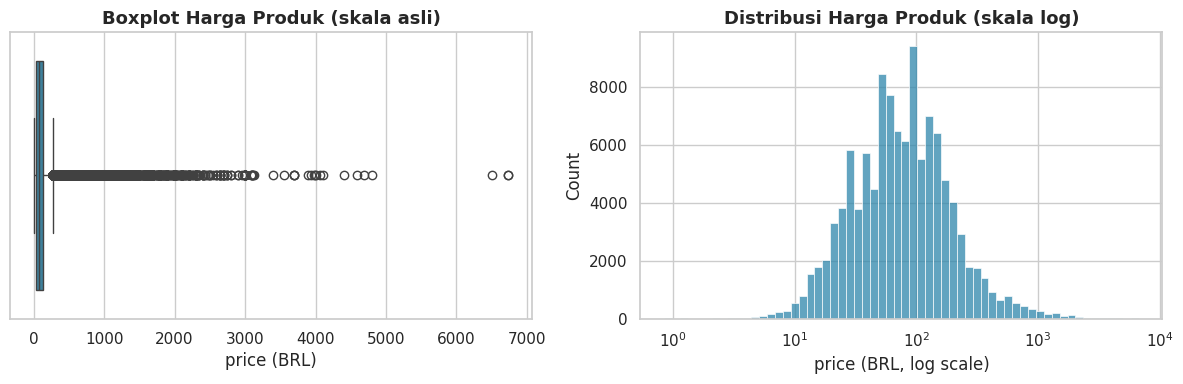

Upper fence (IQR): BRL 277.40  |  7.5% item berada di atas fence ini


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=dfs["items"]["price"], ax=axes[0], color=ACCENT)
axes[0].set_title("Boxplot Harga Produk (skala asli)")
axes[0].set_xlabel("price (BRL)")

sns.histplot(dfs["items"]["price"], bins=60, log_scale=True, ax=axes[1], color=ACCENT)
axes[1].set_title("Distribusi Harga Produk (skala log)")
axes[1].set_xlabel("price (BRL, log scale)")
plt.tight_layout()
plt.show()

q1, q3 = dfs["items"]["price"].quantile([.25, .75])
upper_fence = q3 + 1.5 * (q3 - q1)
pct_outlier = (dfs["items"]["price"] > upper_fence).mean() * 100
print(f"Upper fence (IQR): BRL {upper_fence:,.2f}  |  {pct_outlier:.1f}% item berada di atas fence ini")

**Keputusan data preparation:** Meskipun ±7,5% harga produk berada di atas *IQR fence*, nilai-nilai ini **tidak dihapus**. Berdasarkan pengecekan kategori (`computers`, `small_appliances_home_oven_and_coffee`, dll — barang bernilai tinggi secara wajar), outlier ini merepresentasikan **variasi kategori produk yang sah**, bukan kesalahan input. Karena itu pendekatan yang dipakai adalah **flagging**, bukan *capping/removal*, supaya sewaktu-waktu analisis revenue tidak kehilangan kontribusi dari produk premium.

### 4.8 Menyimpan Analytical Base Table

In [14]:
import os
os.makedirs("../data/processed", exist_ok=True)

abt.to_csv("../data/processed/orders_abt.csv", index=False)
items_abt.to_csv("../data/processed/items_abt.csv", index=False)

print("Tersimpan:")
print(" - data/processed/orders_abt.csv  ", abt.shape)
print(" - data/processed/items_abt.csv   ", items_abt.shape)

Tersimpan:
 - data/processed/orders_abt.csv   (99441, 28)
 - data/processed/items_abt.csv    (112650, 14)


> Kedua file ini menjadi *single source of truth* untuk seluruh EDA di bawah, dan nantinya akan langsung dipakai sebagai **data source untuk web dashboard** di fase project berikutnya — sehingga tidak perlu mengulang proses cleaning dari nol.

## 5. Exploratory Data Analysis & Visualisasi

Mulai dari sini, analisis difokuskan pada order berstatus **`delivered`** (kecuali disebutkan lain) agar metrik bisnis (revenue, waktu kirim, review) mencerminkan transaksi yang benar-benar selesai.

In [15]:
delivered = abt[abt["order_status"] == "delivered"].copy()
print(f"Order 'delivered': {len(delivered):,} dari total {len(abt):,} order ({len(delivered)/len(abt)*100:.1f}%)")

Order 'delivered': 96,478 dari total 99,441 order (97.0%)


### 5.1 Tren Jumlah Order & Revenue per Bulan

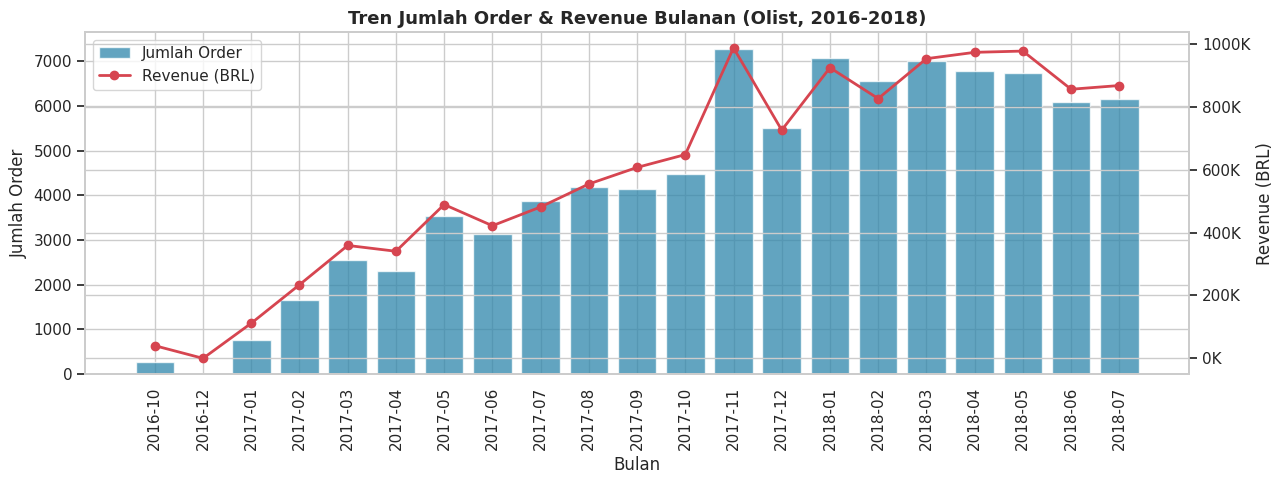

In [16]:
monthly = (delivered
    .groupby("purchase_month")
    .agg(n_orders=("order_id", "count"), revenue=("total_price", "sum"))
    .reset_index()
)
# Buang bulan pertama & terakhir yang datanya tidak penuh (data quality note di bawah)
monthly_plot = monthly.iloc[1:-1]

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(monthly_plot["purchase_month"], monthly_plot["n_orders"], color=ACCENT, alpha=0.75, label="Jumlah Order")
ax2.plot(monthly_plot["purchase_month"], monthly_plot["revenue"], color="#D64550", marker="o", linewidth=2, label="Revenue (BRL)")

ax1.set_ylabel("Jumlah Order")
ax2.set_ylabel("Revenue (BRL)")
ax1.set_xlabel("Bulan")
ax1.set_title("Tren Jumlah Order & Revenue Bulanan (Olist, 2016-2018)")
ax1.tick_params(axis="x", rotation=90)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

**Insight:** Volume order Olist tumbuh sangat pesat sepanjang 2017, lalu relatif stabil di sepanjang 2018 dengan lonjakan tertinggi pada **Agustus 2018** (~6.500 order). Data bulan **September 2016** dan **September–Oktober 2018** sengaja tidak ditampilkan penuh di chart karena baru berisi segelintir baris (indikasi data belum lengkap / terpotong di ujung periode pengumpulan data) — ini juga merupakan bagian penting dari *data preparation*: mengenali dan mengomunikasikan batas keandalan data, bukan menyembunyikannya.

### 5.2 Distribusi Status Order

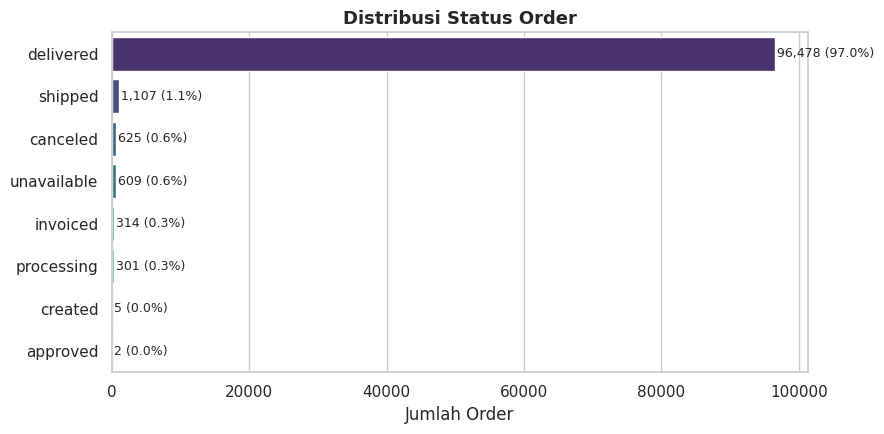

In [17]:
status_counts = abt["order_status"].value_counts()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=status_counts.values, y=status_counts.index, hue=status_counts.index,
            palette=PALETTE, legend=False, ax=ax)
for i, v in enumerate(status_counts.values):
    ax.text(v + 300, i, f"{v:,} ({v/len(abt)*100:.1f}%)", va="center", fontsize=9)
ax.set_title("Distribusi Status Order")
ax.set_xlabel("Jumlah Order")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**Insight:** 97% order berstatus `delivered` — kualitas operasional Olist secara umum baik. Order `canceled` dan `unavailable` masing-masing hanya sekitar 0,6%, menunjukkan tingkat kegagalan transaksi yang rendah.

### 5.3 Performa Pengiriman (Delivery Performance)

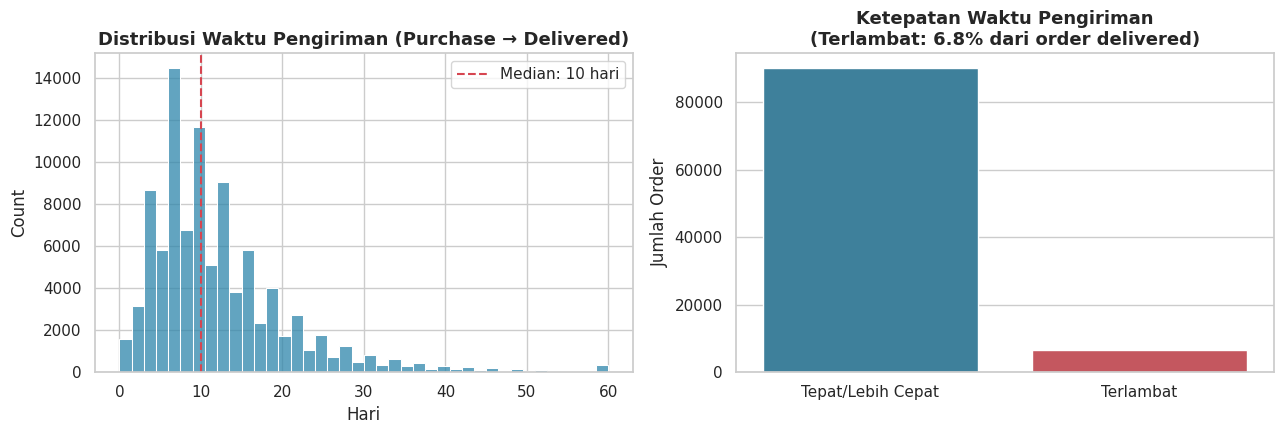

Rata-rata waktu kirim   : 12.1 hari (median 10 hari)
Order terlambat         : 6.77%
Rata-rata keterlambatan : 10.6 hari (di antara order yg telat)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(delivered["delivery_time_days"].clip(upper=60), bins=40, color=ACCENT, ax=axes[0])
axes[0].axvline(delivered["delivery_time_days"].median(), color="#D64550", linestyle="--",
                label=f"Median: {delivered['delivery_time_days'].median():.0f} hari")
axes[0].set_title("Distribusi Waktu Pengiriman (Purchase → Delivered)")
axes[0].set_xlabel("Hari")
axes[0].legend()

late_rate = delivered["is_late"].mean() * 100
sns.countplot(x=delivered["is_late"].map({True: "Terlambat", False: "Tepat/Lebih Cepat"}),
              hue=delivered["is_late"].map({True: "Terlambat", False: "Tepat/Lebih Cepat"}),
              palette={"Terlambat": "#D64550", "Tepat/Lebih Cepat": ACCENT}, legend=False, ax=axes[1])
axes[1].set_title(f"Ketepatan Waktu Pengiriman\n(Terlambat: {late_rate:.1f}% dari order delivered)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Jumlah Order")
plt.tight_layout()
plt.show()

print(f"Rata-rata waktu kirim   : {delivered['delivery_time_days'].mean():.1f} hari (median {delivered['delivery_time_days'].median():.0f} hari)")
print(f"Order terlambat         : {late_rate:.2f}%")
print(f"Rata-rata keterlambatan : {delivered.loc[delivered['is_late'], 'delay_days'].mean():.1f} hari (di antara order yg telat)")

**Insight:** Rata-rata waktu pengiriman **~12 hari** (median 10 hari) — cukup lama untuk standar e-commerce, mengingat luasnya geografi Brazil. Sekitar **6,8% order terlambat** dari estimasi, dengan rata-rata keterlambatan ~10,6 hari saat terjadi. Ini kandidat kuat sebagai *pain point* operasional yang berdampak ke kepuasan pelanggan (lihat 5.4).

### 5.4 Pengaruh Keterlambatan Pengiriman terhadap Review Score

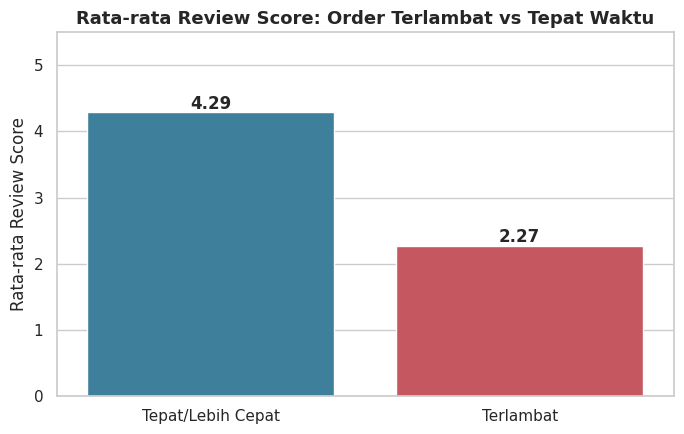

In [19]:
delay_review = (delivered.groupby(delivered["is_late"].map({True: "Terlambat", False: "Tepat/Lebih Cepat"}))
                          ["review_score"].mean().round(2))

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = sns.barplot(x=delay_review.index, y=delay_review.values,
                    hue=delay_review.index,
                    palette={"Terlambat": "#D64550", "Tepat/Lebih Cepat": ACCENT}, legend=False, ax=ax)
for i, v in enumerate(delay_review.values):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontweight="bold")
ax.set_ylim(0, 5.5)
ax.set_title("Rata-rata Review Score: Order Terlambat vs Tepat Waktu")
ax.set_ylabel("Rata-rata Review Score")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

**Insight kunci:** Order yang terlambat rata-rata mendapat review **2,27**, jauh di bawah order tepat waktu yang rata-rata **4,29** — selisih hampir 2 poin dari skala 5. Ini adalah salah satu temuan paling actionable dari seluruh analisis: **ketepatan waktu pengiriman adalah pendorong utama kepuasan pelanggan Olist**, lebih besar pengaruhnya dibanding faktor lain yang akan kita lihat berikutnya.

### 5.5 Distribusi Review Score

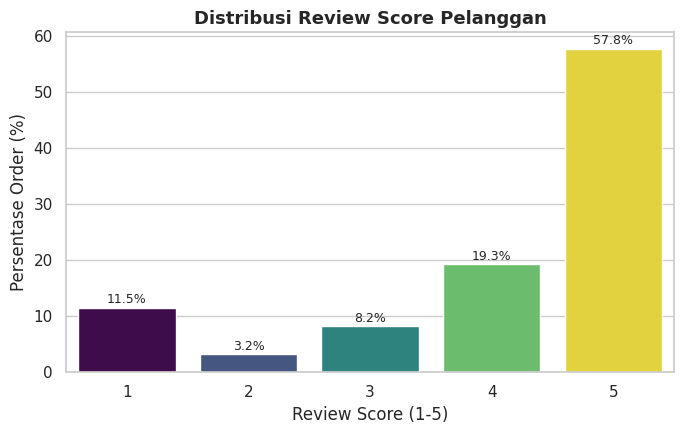

In [20]:
review_counts = abt["review_score"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=review_counts.index.astype(int), y=review_counts.values,
            hue=review_counts.index.astype(int), palette=PALETTE, legend=False, ax=ax)
for i, v in enumerate(review_counts.values):
    ax.text(i, v + 0.8, f"{v:.1f}%", ha="center", fontsize=9)
ax.set_title("Distribusi Review Score Pelanggan")
ax.set_xlabel("Review Score (1-5)")
ax.set_ylabel("Persentase Order (%)")
plt.tight_layout()
plt.show()

**Insight:** Distribusi condong positif — **57,8% order mendapat skor 5**, namun **11,5% mendapat skor 1** (jauh lebih banyak dari skor 2 yang hanya 3,2%). Pola bimodal ini umum di e-commerce: pelanggan puas cenderung memberi skor tinggi, sementara pelanggan yang benar-benar kecewa (kemungkinan besar terkait keterlambatan, lihat 5.4) memilih skor paling rendah, bukan skor menengah.

### 5.6 Metode & Pola Pembayaran

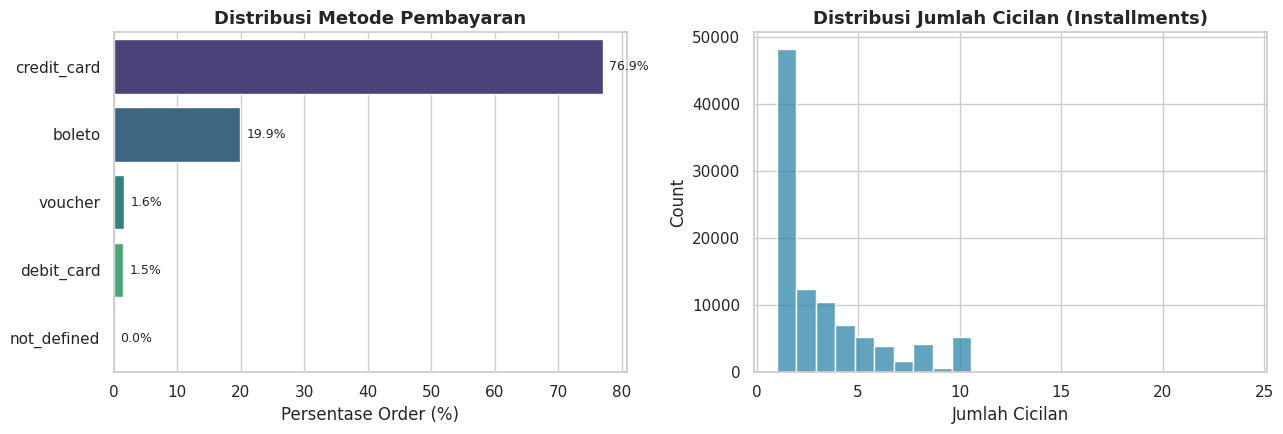

Rata-rata cicilan: 2.93


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

pay_dist = abt["primary_payment_type"].value_counts(normalize=True) * 100
sns.barplot(x=pay_dist.values, y=pay_dist.index, hue=pay_dist.index, palette=PALETTE, legend=False, ax=axes[0])
for i, v in enumerate(pay_dist.values):
    axes[0].text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)
axes[0].set_title("Distribusi Metode Pembayaran")
axes[0].set_xlabel("Persentase Order (%)")
axes[0].set_ylabel("")

sns.histplot(abt.loc[abt["max_installments"] > 0, "max_installments"], bins=24, color=ACCENT, ax=axes[1])
axes[1].set_title("Distribusi Jumlah Cicilan (Installments)")
axes[1].set_xlabel("Jumlah Cicilan")
plt.tight_layout()
plt.show()

print("Rata-rata cicilan:", round(abt["max_installments"].mean(), 2))

**Insight:** **Kartu kredit mendominasi (76,9%)** transaksi, diikuti `boleto` (metode bayar tunai/transfer khas Brazil, 19,9%). Rata-rata pelanggan mencicil **~2,9x** — menandakan cicilan adalah bagian penting dari perilaku belanja di pasar Brazil, relevan untuk strategi promo/pricing bila proyek ini dikembangkan lebih lanjut.

### 5.7 Sebaran Geografis Pelanggan & Seller

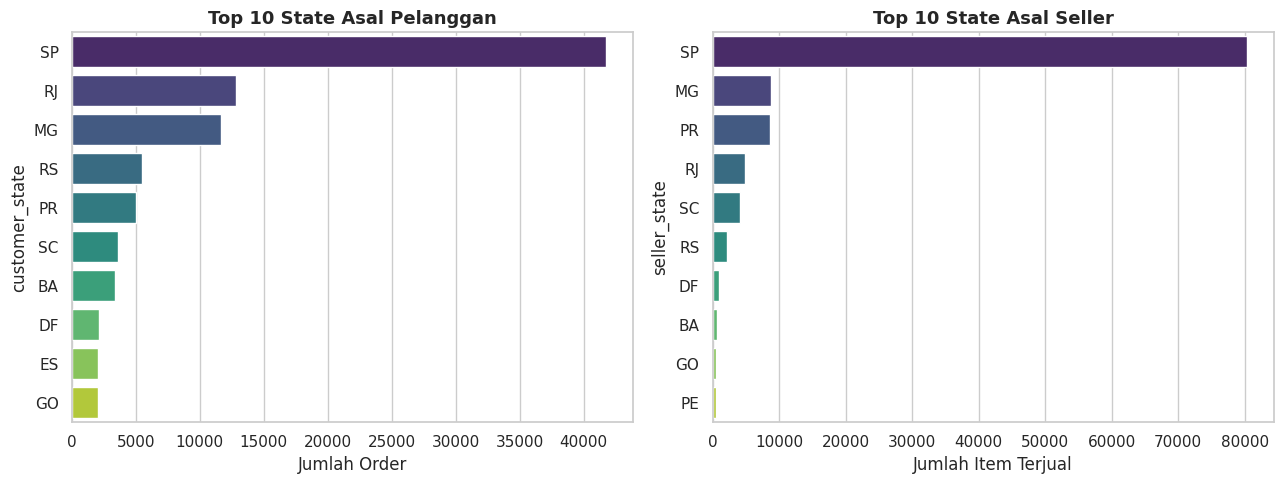

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top_cust_state = abt["customer_state"].value_counts().head(10)
sns.barplot(x=top_cust_state.values, y=top_cust_state.index, hue=top_cust_state.index,
            palette=PALETTE, legend=False, ax=axes[0])
axes[0].set_title("Top 10 State Asal Pelanggan")
axes[0].set_xlabel("Jumlah Order")

top_seller_state = items_abt["seller_state"].value_counts().head(10)
sns.barplot(x=top_seller_state.values, y=top_seller_state.index, hue=top_seller_state.index,
            palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title("Top 10 State Asal Seller")
axes[1].set_xlabel("Jumlah Item Terjual")
plt.tight_layout()
plt.show()

**Insight:** **São Paulo (SP)** mendominasi baik dari sisi pelanggan (42% dari seluruh order) maupun seller (70% dari seluruh item), diikuti Rio de Janeiro dan Minas Gerais. Konsentrasi seller yang jauh lebih ekstrem di SP dibanding sebaran pelanggan yang lebih merata mengindikasikan potensi **kesenjangan jarak pengiriman** ke state lain — salah satu kemungkinan akar penyebab keterlambatan pada temuan 5.3.

### 5.8 Kategori Produk Terlaris

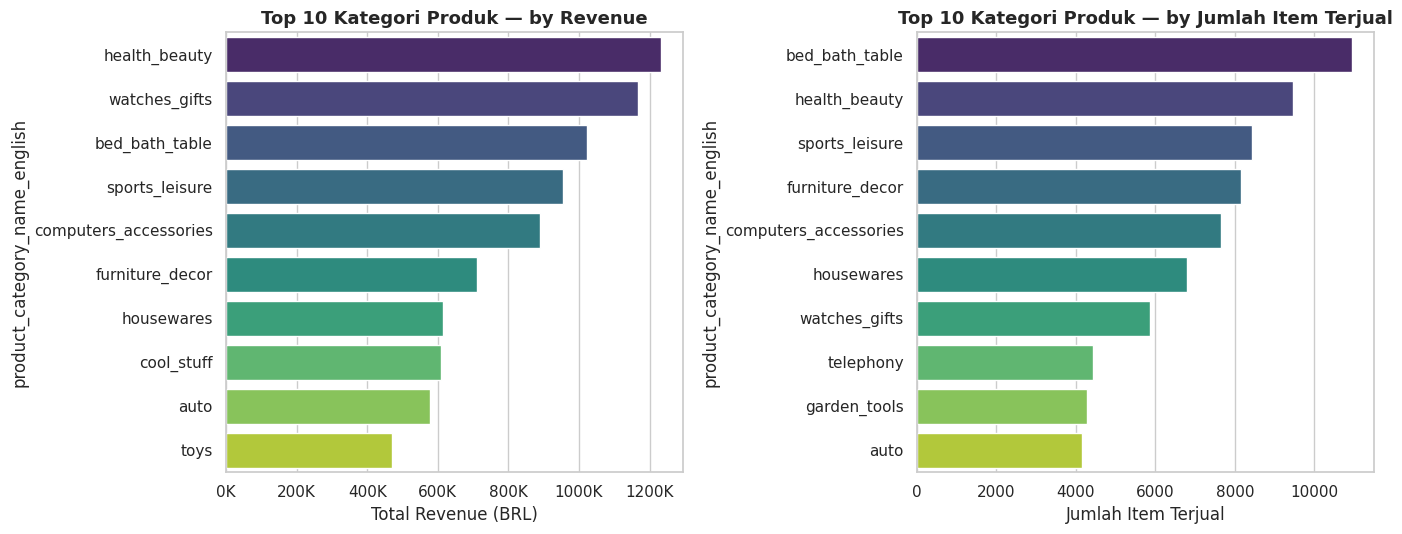

In [23]:
delivered_items = items_abt[items_abt["order_status"] == "delivered"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

top_rev = delivered_items.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_rev.values, y=top_rev.index, hue=top_rev.index, palette=PALETTE, legend=False, ax=axes[0])
axes[0].set_title("Top 10 Kategori Produk — by Revenue")
axes[0].set_xlabel("Total Revenue (BRL)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

top_cnt = delivered_items["product_category_name_english"].value_counts().head(10)
sns.barplot(x=top_cnt.values, y=top_cnt.index, hue=top_cnt.index, palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title("Top 10 Kategori Produk — by Jumlah Item Terjual")
axes[1].set_xlabel("Jumlah Item Terjual")
plt.tight_layout()
plt.show()

**Insight:** `health_beauty` menjadi kategori penyumbang revenue tertinggi, diikuti `watches_gifts` dan `bed_bath_table`. Menariknya `bed_bath_table` justru kategori dengan **volume item terjual terbanyak** meski revenue-nya di bawah `health_beauty` — menunjukkan produk di kategori ini bervolume tinggi namun bernilai per-unit lebih rendah (strategi *volume play*), sementara `health_beauty`/`watches_gifts` lebih ke arah *margin play*.

### 5.9 Pola Waktu Pembelian (Jam & Hari)

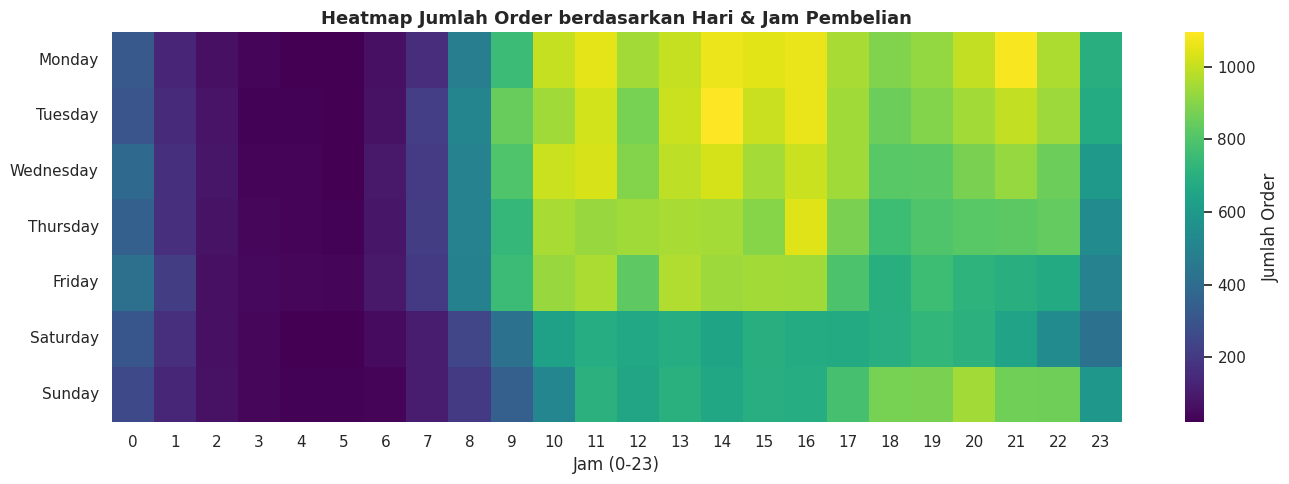

In [24]:
heat_data = (delivered.groupby(["purchase_dow", "purchase_hour"])["order_id"]
             .count().reset_index())
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heat_pivot = heat_data.pivot(index="purchase_dow", columns="purchase_hour", values="order_id").reindex(dow_order)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat_pivot, cmap="viridis", ax=ax, cbar_kws={"label": "Jumlah Order"})
ax.set_title("Heatmap Jumlah Order berdasarkan Hari & Jam Pembelian")
ax.set_xlabel("Jam (0-23)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**Insight:** Aktivitas belanja memuncak pada **jam kerja siang-sore (10.00-16.00)** di hari kerja (Senin-Jumat), dengan penurunan signifikan pada dini hari (00.00-06.00) di semua hari. Pola ini berguna untuk menentukan jadwal optimal kampanye promo/flash sale bila proyek dikembangkan ke arah rekomendasi bisnis.

### 5.10 Pelanggan Baru vs Pelanggan Berulang (Repeat Customer)

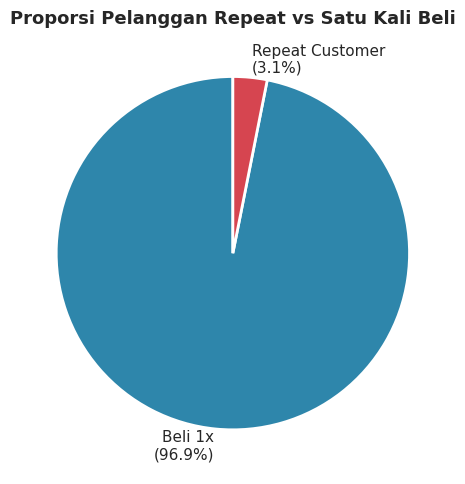

Total pelanggan unik : 96,096
Repeat customer      : 2,997 (3.12%)


In [25]:
orders_per_customer = (abt.groupby("customer_unique_id")["order_id"].nunique())
repeat_flag = (orders_per_customer >= 2)
repeat_pct = repeat_flag.mean() * 100

fig, ax = plt.subplots(figsize=(6, 5))
sizes = [100 - repeat_pct, repeat_pct]
labels = [f"Beli 1x\n({sizes[0]:.1f}%)", f"Repeat Customer\n({sizes[1]:.1f}%)"]
ax.pie(sizes, labels=labels, colors=[ACCENT, "#D64550"], autopct=None, startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Proporsi Pelanggan Repeat vs Satu Kali Beli")
plt.tight_layout()
plt.show()

print(f"Total pelanggan unik : {orders_per_customer.shape[0]:,}")
print(f"Repeat customer      : {repeat_flag.sum():,} ({repeat_pct:.2f}%)")

**Insight:** Hanya **~3,1% pelanggan** yang melakukan order lebih dari satu kali — tingkat retensi yang sangat rendah untuk ukuran marketplace. Ini adalah temuan bisnis paling signifikan dari analisis ini: dengan waktu kirim rata-rata 12 hari dan tingkat repeat purchase serendah ini, **strategi retensi/loyalitas pelanggan** kemungkinan menjadi area terbesar untuk perbaikan bisnis Olist.

### 5.11 Korelasi Antar Metrik Numerik Utama

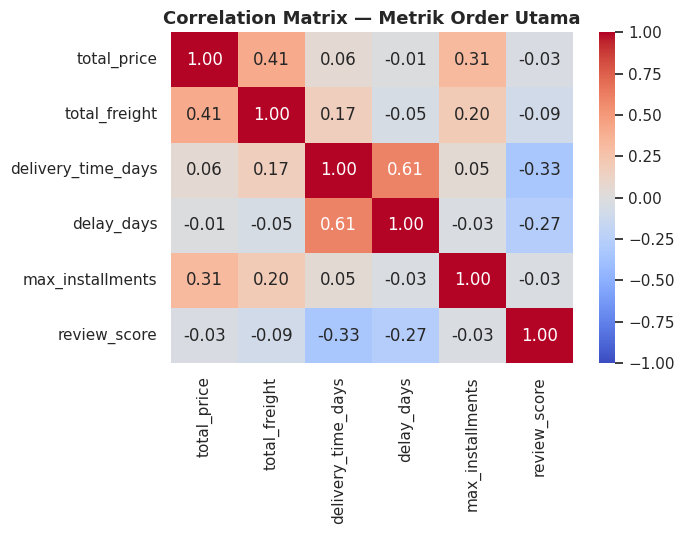

In [26]:
corr_cols = ["total_price", "total_freight", "delivery_time_days", "delay_days",
             "max_installments", "review_score"]
corr = delivered[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix — Metrik Order Utama")
plt.tight_layout()
plt.show()

**Insight:** `delay_days` dan `delivery_time_days` menunjukkan korelasi negatif paling kuat terhadap `review_score` dibanding variabel lain (harga, ongkir, cicilan) — mengonfirmasi ulang temuan 5.4 secara kuantitatif: **faktor operasional (kecepatan & ketepatan kirim), bukan faktor harga**, adalah pendorong dominan kepuasan pelanggan di dataset ini.

## 6. Ringkasan Insight & Rekomendasi Bisnis

| # | Temuan | Rekomendasi |
|---|---|---|
| 1 | Volume order tumbuh pesat sepanjang 2017 lalu stabil di 2018, puncak Agustus 2018 (~6.500 order/bulan) | Gunakan pola musiman ini untuk perencanaan stok & kapasitas logistik jelang bulan-bulan puncak |
| 2 | Rata-rata pengiriman 12 hari, 6,8% order terlambat rata-rata 10,6 hari | Audit *carrier*/seller dengan tingkat keterlambatan tertinggi; SLA lebih ketat untuk order ke luar SP |
| 3 | Order terlambat → review rata-rata 2,27 vs 4,29 (tepat waktu) | Ketepatan waktu adalah *lever* kepuasan pelanggan #1 — prioritaskan investasi di logistik dibanding diskon harga |
| 4 | Kartu kredit 76,9% transaksi, rata-rata cicilan 2,9x | Pastikan partner payment gateway mendukung cicilan fleksibel, terutama untuk kategori bernilai tinggi |
| 5 | Seller 70% terkonsentrasi di SP, pelanggan tersebar lebih merata | Dorong onboarding seller di luar SP untuk memperpendek jarak kirim ke state lain |
| 6 | `health_beauty`, `watches_gifts`, `bed_bath_table` = kategori revenue tertinggi | Alokasikan budget marketing/promo lebih besar ke kategori-kategori ini |
| 7 | Hanya 3,1% pelanggan yang repeat order | Rancang program loyalitas / retargeting pasca-pembelian pertama — potensi upside terbesar untuk revenue jangka panjang |
| 8 | Korelasi delay & review score jauh lebih kuat dibanding harga/cicilan terhadap review score | Fokus perbaikan CX di sisi operasional logistik, bukan hanya pricing |

## 7. Langkah Selanjutnya — Menuju Web Dashboard

Notebook ini adalah **fase 1 (EDA & Data Preparation)** dari project portofolio besar. Output `data/processed/orders_abt.csv` dan `items_abt.csv` dirancang agar bisa langsung dipakai sebagai *data source* fase berikutnya, tanpa mengulang proses cleaning:

- **Fase 2 — Web Dashboard:** membangun dashboard interaktif (mis. Streamlit / Plotly Dash / atau backend API + frontend charting) yang menyajikan KPI utama secara live-filterable: tren order & revenue, delivery performance, top kategori, dan peta sebaran state.
- **KPI card yang disarankan untuk halaman utama dashboard:** total revenue, total order, rata-rata waktu kirim, % order terlambat, rata-rata review score, % repeat customer.
- **Filter interaktif yang berguna:** rentang tanggal, state pelanggan, kategori produk, status order.
- **(Opsional, fase 3):** analisis sentimen review (`review_comment_message`) — bagian ini butuh penanganan teks berbahasa Portugis (translasi/model NLP multibahasa) sesuai notebook Kaggle acuan, dan bisa jadi *value-add* lanjutan setelah dashboard inti selesai.

---
*Dataset: [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) — CC BY-NC-SA 4.0. Notebook ini dibuat untuk keperluan latihan & portofolio pribadi, terinspirasi dari struktur analisis pada notebook Kaggle karya Thiago Panini.*